Environment Setup

In [1]:
import sys
sys.path.insert(0, "/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin/src")

Verify Hardware and PyTorch Environment

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.14.0.dev20260710+rocm7.2
True
AMD Instinct MI300X VF


Synchronise Repository

In [3]:
!cd "/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin" && git pull

Already up to date.


Run Batch Benchmarks

In [4]:
%run "/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin/scripts/step3_batch_benchmark.py"

Generated pool of 2048 frames, patch shape (32, 32)

     N   serial(s)   serial ms/f      gpu(s)    gpu ms/f   speedup
     8      0.0550        6.8694      0.0013      0.1640    41.88x
    32      0.3195        9.9842      0.0063      0.1958    50.99x
   128      0.8565        6.6912      0.0090      0.0704    95.07x
   512      3.7754        7.3738      0.0148      0.0290   254.50x
  2048     14.9735        7.3113      0.0403      0.0197   371.39x


Change Working Directory

In [5]:
%cd "/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin"

/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin


Run Serial Baseline Performance Profiling

frame    0  lag=0.0116s  run elapsed=0.2s
frame  200  lag=0.0053s  run elapsed=5.6s
frame  400  lag=0.0046s  run elapsed=7.8s
frame  600  lag=0.0361s  run elapsed=10.6s
frame  800  lag=0.0135s  run elapsed=13.5s
frame 1000  lag=0.0047s  run elapsed=16.3s
frame 1200  lag=0.0063s  run elapsed=19.3s
frame 1400  lag=0.0101s  run elapsed=22.3s
frame 1600  lag=0.0059s  run elapsed=25.3s
frame 1800  lag=0.0051s  run elapsed=28.1s

Saved 2000 rows to scripts/serial_baseline_staleness.csv
lag: min=0.0038s max=0.1565s mean=0.0081s
Saved plot to scripts/serial_baseline_staleness.png


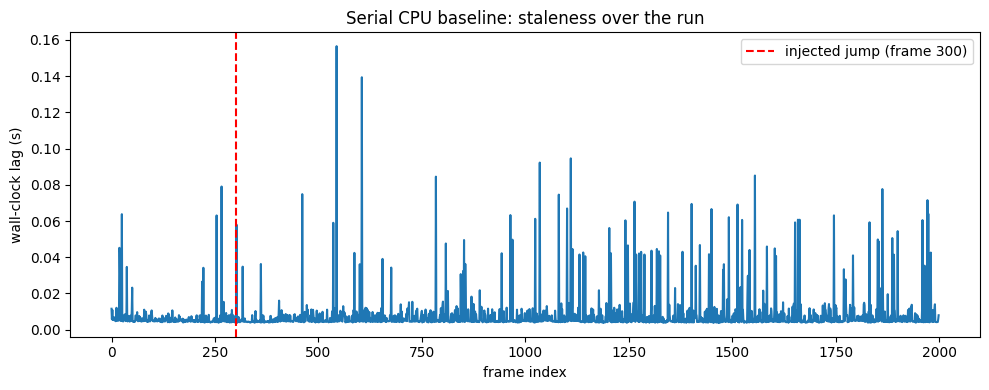

In [6]:
%run scripts/run_serial_baseline.py

Evaluate Out-Of-Distribution (OOD) Drift Signals

frame    0  disagreement=0.017390  ood_anomalous=False
frame  200  disagreement=0.011264  ood_anomalous=False
frame  400  disagreement=0.010672  ood_anomalous=False
frame  600  disagreement=0.006679  ood_anomalous=False
frame  800  disagreement=0.003972  ood_anomalous=False
frame 1000  disagreement=0.001928  ood_anomalous=False
frame 1200  disagreement=0.000646  ood_anomalous=False
frame 1400  disagreement=0.000130  ood_anomalous=False
frame 1600  disagreement=0.000092  ood_anomalous=False
frame 1800  disagreement=0.000092  ood_anomalous=False

Ran 2000 frames in 33.3s
OOD flag fired on 23 / 2000 frames
disagreement: min=0.000092 max=0.017478 mean=0.004380 std=0.005012
OOD fired at frame indices (first 30 shown): [11, 144, 146, 300, 301, 302, 485, 486, 661, 662, 815, 816, 817, 971, 972, 973, 1124, 1125, 1126, 1280, 1281, 1479, 1480]
Saved plot to scripts/step4_drift_signals.png


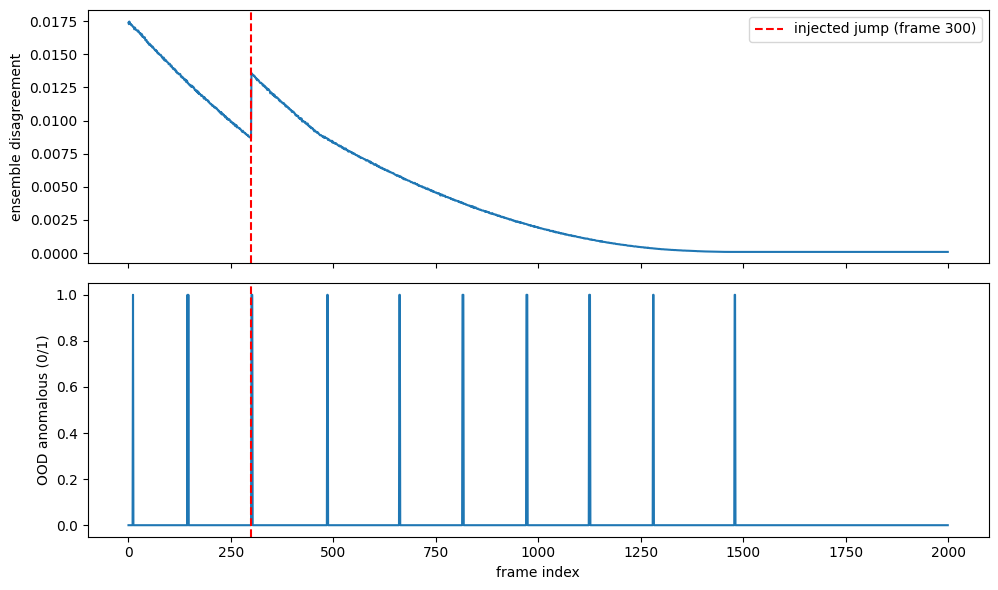

In [7]:
%run scripts/step4_drift_signals.py

Triage Sanity Check

In [8]:
%run scripts/step5_triage_sanity_check.py

 queue  stale(s)  drift  decision   note
     0     0.001  False      FULL   no pressure at all
     5     0.001  False      FULL   light backlog, fresh -- should still be FULL, budget available
    20     0.010  False      SKIP   moderate backlog, fresh -- CHEAP, bridging
    20     0.080  False      SKIP   moderate backlog, stale -- FULL wins, correctness debt
    80     0.010  False      SKIP   severe backlog, fresh -- SKIP, shed load
    80     0.080  False      SKIP   severe backlog AND stale -- still SKIP, queue check comes first
    80     0.010   True      FULL   severe backlog, but drift active -- FULL overrides everything
     0     0.090  False      FULL   no backlog but very stale -- FULL, pay down debt


Run Full System Demo and Comparison

Warming up CPU and GPU ensembles...
Running serial...
Running batched...
Running batched_triage...
  tier decisions: {'FULL': 231, 'CHEAP': 17, 'SKIP': 43}  (max queue depth seen: 16)
  tier compute time (s): {'FULL': 0.33402711499991256, 'CHEAP': 0.0136637600000995, 'SKIP': 3.0221999963941926e-05}
         serial: min=0.0038s max=0.2551s mean=0.0085s
        batched: min=0.0013s max=0.0548s mean=0.0099s
 batched_triage: min=0.0001s max=0.0214s mean=0.0096s


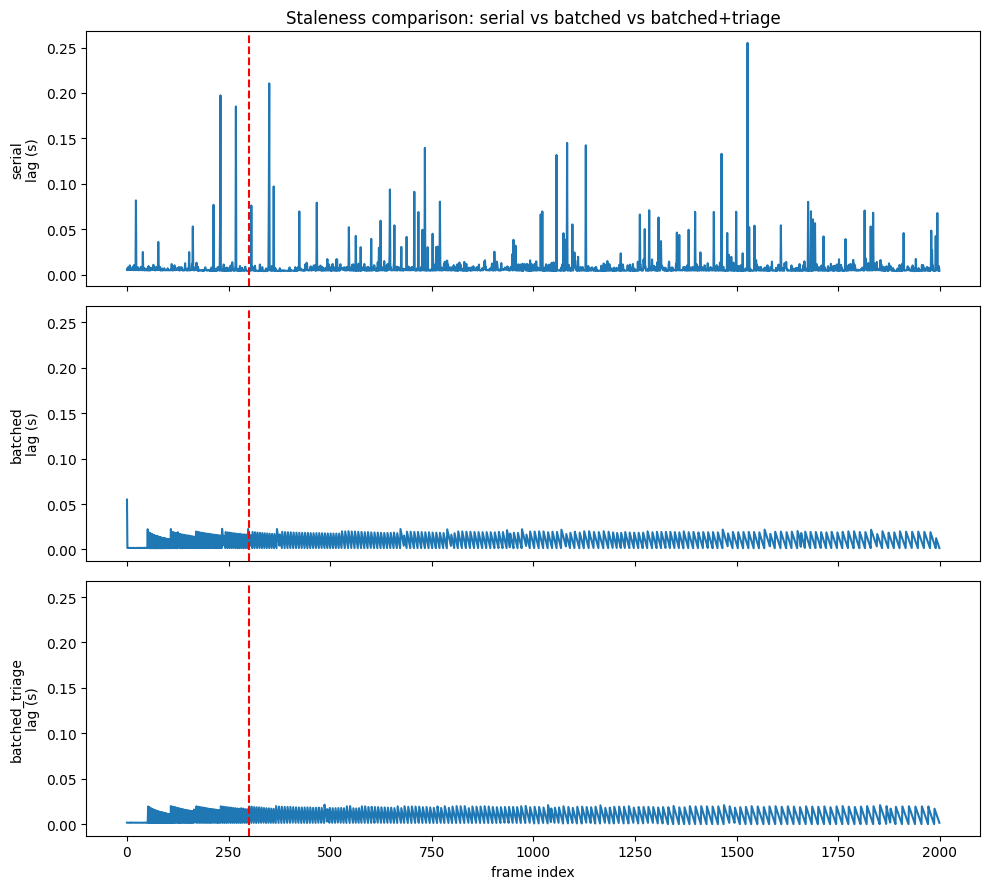


Saved scripts/full_comparison.png


In [9]:
%run scripts/run_full_demo.py

Import and Test Pipeline Manually

In [10]:
from qdot_twin.pipeline import run
log = run("batched_triage", "configs/trajectory.yaml")

  tier decisions: {'FULL': 233, 'CHEAP': 19, 'SKIP': 42}  (max queue depth seen: 16)
  tier compute time (s): {'FULL': 0.34162459199984596, 'CHEAP': 0.016100805999883505, 'SKIP': 2.2766000142837584e-05}


Install Editable Package (Fetches OpenAI and QCoDeS Dependencies)

In [11]:
!pip install -e .

Obtaining file:///shared-docker/SimQuantum-AMD-Developer-Hackathon/Act%20II/qdot-live-twin
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for qdot-twin (pyproject.toml) ... done
  Created wheel for qdot-twin: filename=qdot_twin-0.1.0-0.editable-py3-none-any.whl size=1380 sha256=c85710fc69f54df9fa69400c30ef2f03b108baefaca9fb512ed19f5e3e1595a9
  Stored in directory: /tmp/pip-ephem-wheel-cache-skxu1tq9/wheels/fd/f3/6a/ca518160ab5f62866947dcbb641159b0e6ceadb7fc758dd02c
Successfully built qdot-twin
  Attempting uninstall: qdot-twin
    Found existing installation: qdot-twin 0.1.0
    Uninstalling qdot-twin-0.1.0:
      Successfully uninstalled qdot-twin-0.1.0


Set Fireworks API Key Environment Variable

In [12]:
import os
os.environ["FIREWORKS_API_KEY"] = "fw_5iE29uWcGoUs1Qwk2h9oQj"

In [13]:
!curl -s https://api.fireworks.ai/inference/v1/chat/completions \
  -H "Authorization: Bearer $FIREWORKS_API_KEY" \
  -H "Content-Type: application/json" \
  -d '{"model": "accounts/fireworks/models/llama-v3p1-8b-instruct", "messages": [{"role":"user","content":"say hi"}], "max_tokens": 10}'

/bin/bash: line 1: curl: command not found


In [14]:
!echo ${#FIREWORKS_API_KEY}

25


Run LLM Supervisor Sanity Check

In [15]:
!python scripts/step6b_llm_supervisor_check.py

Scenario A: sustained heavy backlog, no drift
  before: cheap_queue_depth=10 skip_queue_depth=12 stale_threshold_s=0.05
  after:  cheap_queue_depth=10 skip_queue_depth=12 stale_threshold_s=0.05
  reasoning: [error, thresholds unchanged] NotFoundError("Error code: 404 - {'error': {'message': 'Model not found, inaccessible, and/or not deployed', 'param': 'model', 'code': 'NOT_FOUND', 'type': 'error'}, 'request_id': 'chatcmpl-a5ade51374d8473699c093b8b6af3d58'}")

Scenario B: light backlog, thresholds never approached
  before: (10, 12, 0.05)
  after:  (10, 12, 0.05)
  reasoning: [error, thresholds unchanged] NotFoundError("Error code: 404 - {'error': {'message': 'Model not found, inaccessible, and/or not deployed', 'param': 'model', 'code': 'NOT_FOUND', 'type': 'error'}, 'request_id': 'chatcmpl-6e3fdc841a9b46feb61edb23e8e848fb'}")

If both scenarios show a real event with sane (non-error) reasoning and
thresholds that stayed within bounds, the supervisor is ready to wire into
the full pip

Run QCoDeS Integration Demo

In [16]:
!python scripts/qcodes_demo.py

[qdot_twin_source(QArrayTwinInstrument)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/qcodes/instrument/instrument.py", line 100, in get_idn
    idstr = self.ask("*IDN?")
            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/qcodes/instrument/instrument.py", line 445, in ask
    raise e
  File "/usr/local/lib/python3.12/dist-packages/qcodes/instrument/instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
             ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/qcodes/instrument/instrument.py", line 459, in ask_raw
    raise NotImplementedError(
NotImplementedError: ('Instrument QArrayTwinInstrument has not defined an ask method', "asking '*IDN?' to <QArrayTwinInstrument: qdot_twin_source>")
QCoDeS Station registered:
  instruments: ['qdot_twin_source']

Pulling 5 frames through the QCoDeS Parameter interface...
  frame_index=0  vx=-5.0031  vy=-5.0128  fr

Launch Streamlit Web Application

In [17]:
import subprocess, time
from pyngrok import ngrok

subprocess.run("pkill -9 -f streamlit", shell=True)
time.sleep(1)
log_file = open("streamlit.log", "a")
proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.address", "0.0.0.0", "--server.port", "8501"],
    stdout=log_file, stderr=subprocess.STDOUT,
)
time.sleep(3)
ngrok.kill()  # clear any stale tunnel before opening a new one
public_url = ngrok.connect(8501)
print("PID:", proc.pid, "| URL:", public_url)

PID: 524181 | URL: NgrokTunnel: "https://rylee-colorfast-berenice.ngrok-free.dev" -> "http://localhost:8501"
